### Es 1
Hai a disposizione un file `data.csv` contenente dati mensili di traffico aereo con due colonne:

- `date`: data in formato `YYYY-MM` (mese/anno)
- `passengers`: numero di passeggeri per quel mese


Costruisci un modello di **regressione polinomiale** che approssima l’andamento del numero di passeggeri nel tempo.

1. Carica il dataset.
2. Convertilo in un formato numerico utilizzando una colonna `mese_numerico` che conti i mesi a partire da gennaio 1949.
3. Applica una regressione polinomiale (grado a tua scelta).
4. Calcola l’RMSE tra i valori reali e quelli predetti.
5. Visualizza i dati reali e la curva stimata con Plotly.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import plotly.graph_objects as go
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

df = pd.read_csv('data.csv')
df

df = df.dropna()


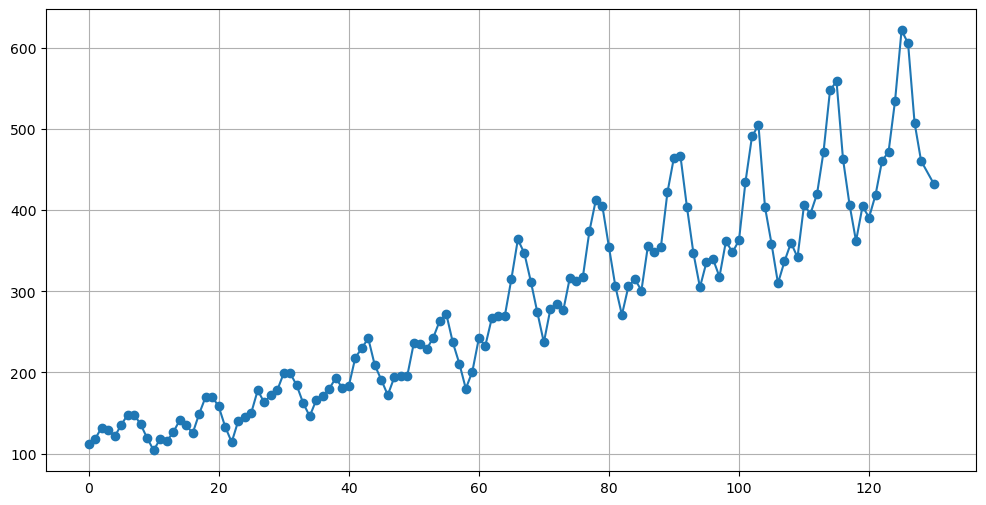

In [31]:
#real data
plt.figure(figsize=(12,6))
plt.plot(df.index.values, df['passengers'].values, marker='o')
plt.grid(True)
plt.show()

In [33]:
df['mese_numerico'] = np.arange(len(df))

X = df['mese_numerico'].values.reshape(-1, 1)
y = df['passengers'].values


#split delle osservazioni test-training
x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42)

#pipeline e polynomial regression
model_poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
model_poly2.fit(x_train, y_train)

y_pred_poly2 = model_poly2.predict(x_test)


In [39]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae_ploy2 = mean_absolute_error(y_test, y_pred_poly2)
rmse_poly2 = root_mean_squared_error(y_test, y_pred_poly2)

print(f"MAE: {mae_ploy2:.2f}")
print(f"RMSE: {rmse_poly2:.2f}")

MAE: 31.59
RMSE: 43.44


In [ ]:
import plotly.graph_objects as go

#Chiediamo al modello la predizione su TUTTI i mesi a disposizione
y_pred_totale = model_poly2.predict(df['mese_numerico'].values.reshape(-1,1))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['mese_numerico'], 
    y=df['passengers'], 
    mode='markers',
    name='Dati Reali'
))

fig.add_trace(go.Scatter(
    x=df['mese_numerico'], 
    y=y_pred_totale, 
    mode='lines',
    name='Curva Stimata (Poly 2)',
    line=dict(color='red', width=2)
))

fig.update_layout(
    title='Traffico aereo mensile: Dati reali vs Regressione Polinomiale', 
    xaxis_title='Mesi (da Gen 1949)', 
    yaxis_title='Numero di Passeggeri'
)

fig.show()